In [ ]:
#  lstm stock market

In [ ]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [ ]:
#import data
dataset_train = pd.read_csv("googlestockpricetrain (1).csv")

In [ ]:
dataset_train.head()

,Date,Open,High,Low,Close,Volume
0,01/03/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,01/04/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,01/05/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,01/06/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,01/09/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [ ]:
#keras only takes numpy array
training_set=dataset_train.iloc[:, 1:2].values

In [ ]:
training_set.shape

(1509, 1)

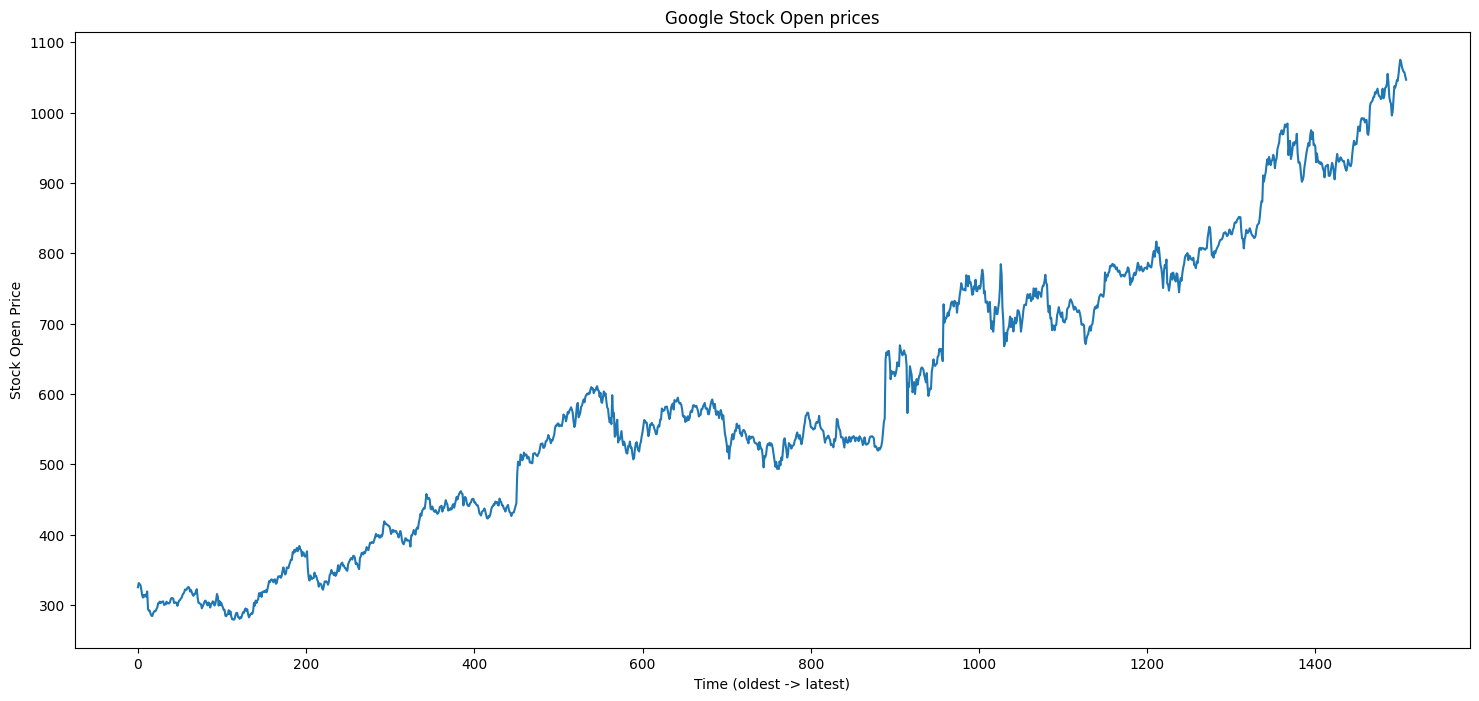

In [ ]:
plt.figure(figsize=(18, 8))
plt.plot(dataset_train['Open'])
plt.title("Google Stock Open prices")
plt.xlabel("Time (oldest -> latest)")
plt.ylabel("Stock Open Price")
plt.show()


In [ ]:
#feature scaling
sc=MinMaxScaler(feature_range=(0, 1))
# fit: get min/max of train data
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
#60 timesteps and 1 output
X_train =[]
y_train=[]
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60: i, 0])
    y_train.append(training_set_scaled[ i, 0])
X_train, y_train = np.array(X_train), np .array(y_train)

In [ ]:
X_train.shape

(1449, 60)

In [ ]:
y_train.shape

(1449,)

In [ ]:
X_train = np.reshape(X_train, newshape = (X_train.shape[0],X_train.shape[1],1))

C:\Users\HP\AppData\Local\Temp\ipykernel_316\2013788466.py:1: DeprecationWarning: `newshape` keyword argument is deprecated, use `shape=...` or pass shape positionally instead. (deprecated in NumPy 2.1)
  X_train = np.reshape(X_train, newshape = (X_train.shape[0],X_train.shape[1],1))


In [ ]:
X_train

array([[[0.05794644],
        [0.0655085 ],
        [0.06369963],
        ...,
        [0.05298463],
        [0.05425334],
        [0.05738117]],

       [[0.0655085 ],
        [0.06369963],
        [0.06182796],
        ...,
        [0.05425334],
        [0.05738117],
        [0.05826048]],

       [[0.06369963],
        [0.06182796],
        [0.05391418],
        ...,
        [0.05738117],
        [0.05826048],
        [0.05720531]],

       ...,

       [[0.85526583],
        [0.84775405],
        [0.85152251],
        ...,
        [0.98712441],
        [0.98230082],
        [0.97848205]],

       [[0.84775405],
        [0.85152251],
        [0.84962571],
        ...,
        [0.98230082],
        [0.97848205],
        [0.97762796]],

       [[0.85152251],
        [0.84962571],
        [0.86370723],
        ...,
        [0.97848205],
        [0.97762796],
        [0.97035477]]], shape=(1449, 60, 1))

In [ ]:
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=False))
regressor.add(Dropout(0.2))

regressor.add(Dense(units =1))

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
regressor.compile(optimizer = 'adam',loss = 'mean_squared_error')

In [ ]:
regressor.fit(x = X_train, y=y_train, batch_size =32,epochs=100)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - loss: 0.0252
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0042
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0037
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0039
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0035
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0031
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0029
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0027
Epoch 9/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0024
Epoch 10/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0026
Epoch 11/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0026
Epoch 12/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0022
Epoch 13/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0021
Epoch 14/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0025
Epoch 15/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - lo

In [ ]:
dataset_test=pd.read_csv("googlestockpricetest (1).csv")

In [ ]:
dataset_test.head()

,Date,Open,High,Low,Close,Volume
0,02/01/2018,1048.339966,1066.939941,1045.229980,1065.000000,1237600
1,03/01/2018,1064.310059,1086.290039,1063.209961,1082.479980,1430200
2,04/01/2018,1088.000000,1093.569946,1084.001953,1086.400024,1004600
3,05/01/2018,1094.000000,1104.250000,1092.000000,1102.229980,1279100
4,08/01/2018,1102.229980,1111.270020,1101.619995,1106.939941,1047600


In [ ]:
real_stock_price=dataset_test.iloc[:, 1: 2].values
real_stock_price.shape

(125, 1)

In [ ]:
#vertical concat use 0, horizotal uses 1
dataset_total = pd.concat((dataset_train['Open'],dataset_test['Open']),axis=0)
#use values to make numpy array
inputs =dataset_total[len(dataset_total)-len(dataset_test) - 60:].values

In [ ]:
# reshape data to only have 1 col
inputs=inputs.reshape(-1, 1)
#scale input

In [ ]:
inputs=sc.transform(inputs)

In [ ]:
len(inputs)

185

In [ ]:
X_test=[]
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
X_test=np.array(X_test)
X_test=np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [ ]:
X_test.shape

(125, 60, 1)

In [ ]:
predicted_stock_price =regressor.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step


In [ ]:
#inverse the scaled value
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

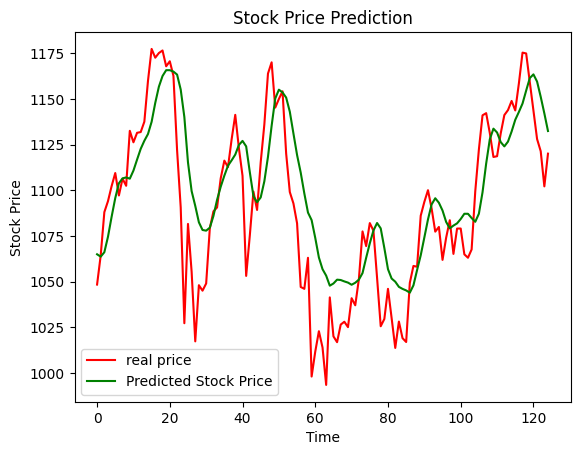

In [ ]:
#visualize the prediction and real price
plt.plot(real_stock_price,color='red',label='real price')
plt.plot(predicted_stock_price,color='green',label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()